# PPSeq Sequence Detection

This tutorial shows how to use `PPSeq` to learn repeated neural sequence templates during behavior and score those same templates during post-task sharp wave ripples.

The workflow is:

1. Bin spikes into a `(n_neurons, n_time_bins)` count matrix.
2. Fit PPSeq templates on task/behavior data.
3. Freeze those templates and infer their strengths in post-task data.
4. Summarize template strength and likelihood gain for each ripple.

The first half uses simulated data so the expected sequence identity is known. The second half shows the same analysis pattern with real CellExplorer-style session data loaded through `neuro_py`.

## Simulated task and post-task data

Create a larger synthetic dataset with 75 neurons and three recurring sequence motifs. Background spikes are mixed in, so the raster looks more like a real session than a toy diagonal.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from neuro_py.ensemble.ppseq import (
    PPSeq,
    ppseq_seed_stability,
    select_ppseq_template_count,
)

In [2]:
def simulate_ppseq_spikes(
    sequence_orders,
    sequence_starts,
    *,
    n_neurons=75,
    duration=22.0,
    template_duration_s=0.55,
    background_rate=0.55,
    sequence_spike_prob=0.86,
    jitter=0.012,
    seed=0,
):
    rng = np.random.default_rng(seed)
    spike_times = []
    neuron_ids = []
    sequence_ids = []

    for neuron in range(n_neurons):
        n_background = rng.poisson(background_rate * duration)
        spike_times.extend(rng.uniform(0, duration, n_background))
        neuron_ids.extend([neuron] * n_background)
        sequence_ids.extend([-1] * n_background)

    for sequence_id, starts in sequence_starts.items():
        order = np.asarray(sequence_orders[sequence_id], dtype=int)
        offsets = np.linspace(0.03, template_duration_s - 0.03, len(order))
        for start in starts:
            for neuron, offset in zip(order, offsets):
                if rng.random() > sequence_spike_prob:
                    continue
                spike_t = start + offset + rng.normal(0, jitter)
                if 0 <= spike_t <= duration:
                    spike_times.append(spike_t)
                    neuron_ids.append(int(neuron))
                    sequence_ids.append(sequence_id)

    order = np.argsort(spike_times)
    return (
        np.asarray(spike_times)[order],
        np.asarray(neuron_ids, dtype=int)[order],
        np.asarray(sequence_ids, dtype=int)[order],
    )


n_neurons = 75
bin_size = 0.02
duration = 22.0
template_duration_s = 0.55
template_duration = int(np.round(template_duration_s / bin_size))

sequence_orders = {
    0: np.arange(16, 46),
    1: np.arange(47, 74),
    2: np.arange(32, 5, -1),
}
task_sequence_starts = {
    0: [0.8, 2.1, 4.7, 5.7, 7.8, 9.5, 12.2, 15.2, 16.7, 18.5, 20.8],
    1: [1.3, 2.8, 3.5, 8.6, 9.9, 10.7, 11.5, 13.1, 14.1, 17.0, 18.1, 19.6, 20.3],
    2: [0.4, 3.9, 6.5, 8.2, 11.9, 14.8, 16.0, 18.8, 21.1],
}

task_spike_times, task_neuron_ids, true_sequence_ids = simulate_ppseq_spikes(
    sequence_orders,
    task_sequence_starts,
    n_neurons=n_neurons,
    duration=duration,
    template_duration_s=template_duration_s,
    seed=2,
)

binning_model = PPSeq(
    n_templates=3,
    template_duration=template_duration,
    n_neurons=n_neurons,
    bin_size=bin_size,
)
task_counts, task_time_centers = binning_model.bin_spikes(
    task_spike_times,
    task_neuron_ids,
    start=0.0,
    stop=duration,
    n_neurons=n_neurons,
)

Before fitting PPSeq, plot the simulated task raster using the known sequence identity from the simulator. Background spikes are black; the three embedded sequence motifs are colored.

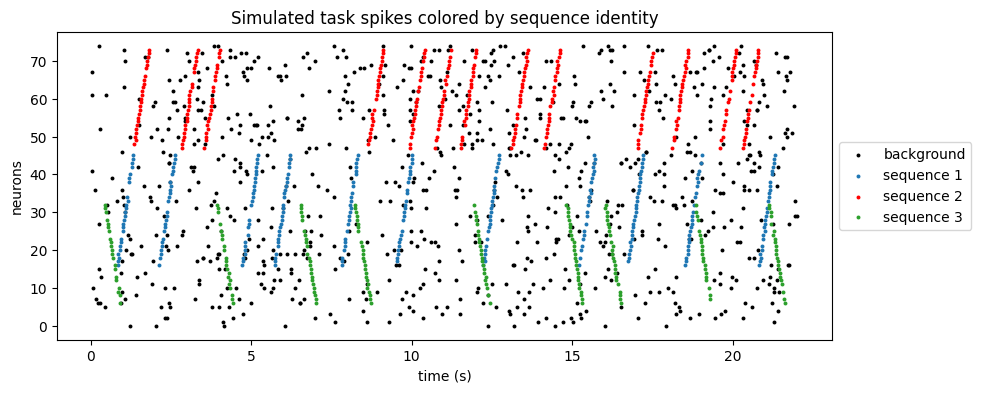

In [3]:
sequence_colors = {
    -1: "black",
    0: "tab:blue",
    1: "red",
    2: "tab:green",
}
sequence_labels = {
    0: "sequence 1",
    1: "sequence 2",
    2: "sequence 3",
}

fig, ax = plt.subplots(figsize=(10, 4))
background = true_sequence_ids < 0
ax.scatter(
    task_spike_times[background],
    task_neuron_ids[background],
    s=8,
    c=sequence_colors[-1],
    linewidths=0,
    label="background",
)
for sequence_id, label in sequence_labels.items():
    idx = true_sequence_ids == sequence_id
    ax.scatter(
        task_spike_times[idx],
        task_neuron_ids[idx],
        s=8,
        c=sequence_colors[sequence_id],
        linewidths=0,
        label=label,
    )
ax.set_xlabel("time (s)")
ax.set_ylabel("neurons")
ax.set_title("Simulated task spikes colored by sequence identity")
# move legend outside of plot
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.show()

Fit three PPSeq templates during behavior. Here `template_duration` is in bins, so with a 20 ms bin size the template spans a little over 500 ms.

In [4]:
ppseq = PPSeq(
    n_templates=3,
    template_duration=template_duration,
    n_neurons=n_neurons,
    bin_size=bin_size,
    sequence_frac=0.8,
    random_state=1,
)

fit_result = ppseq.fit(task_counts, num_iter=60)

fit_result.log_likelihood[-5:]

array([-6880.70949924, -6879.69212959, -6878.71375621, -6877.77148729,
       -6876.86261288])

Next, color the same task raster by PPSeq-detected template identity. This uses peaks in the fitted template-amplitude traces to mark likely sequence events. Spikes outside detected event windows remain black.

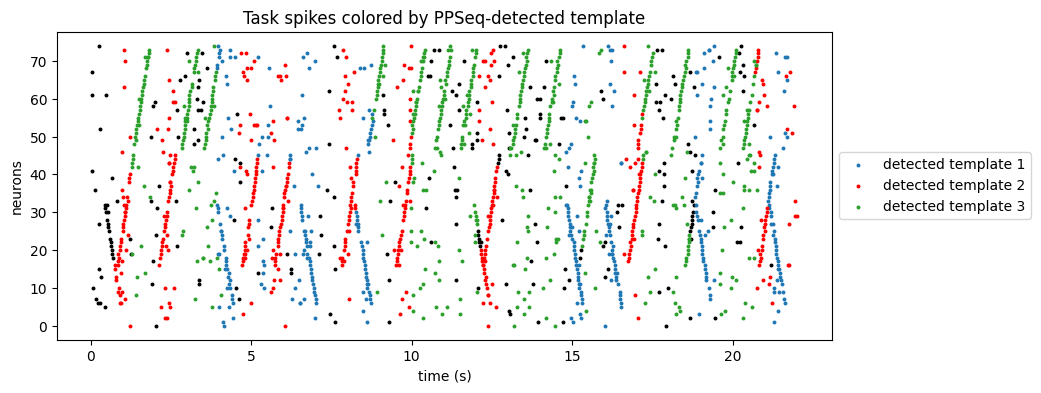

In [5]:
def detect_template_events(amplitudes, time_centers, *, percentile=96.5, refractory_s=0.38):
    candidates = []
    dt = np.median(np.diff(time_centers))
    refractory_bins = max(1, int(np.round(refractory_s / dt)))

    for template_id, amp in enumerate(amplitudes):
        threshold = np.percentile(amp, percentile)
        peaks = np.where(
            (amp[1:-1] >= amp[:-2])
            & (amp[1:-1] >= amp[2:])
            & (amp[1:-1] >= threshold)
        )[0] + 1
        for idx in peaks:
            candidates.append((idx, template_id, amp[idx]))

    candidates = sorted(candidates, key=lambda item: item[2], reverse=True)
    accepted = []
    for idx, template_id, amplitude in candidates:
        if all(abs(idx - prev_idx) > refractory_bins for prev_idx, _, _ in accepted):
            accepted.append((idx, template_id, amplitude))

    return sorted(
        [(time_centers[idx], template_id, amplitude) for idx, template_id, amplitude in accepted],
        key=lambda item: item[0],
    )


detected_events = detect_template_events(fit_result.amplitudes, task_time_centers)
detected_template_ids = np.full(task_spike_times.shape, -1, dtype=int)

events_by_strength = sorted(detected_events, key=lambda item: item[2], reverse=True)
for event_time, template_id, _ in events_by_strength:
    offsets_s = ppseq.template_offsets_[template_id, task_neuron_ids] * bin_size
    widths_s = ppseq.template_widths_[template_id, task_neuron_ids] * bin_size
    expected_spike_times = event_time + offsets_s
    spike_tolerance = np.maximum(0.035, 2.5 * widths_s)
    in_template = (
        (detected_template_ids < 0)
        & (task_spike_times >= event_time - 0.03)
        & (task_spike_times <= event_time + template_duration_s + 0.03)
        & (np.abs(task_spike_times - expected_spike_times) <= spike_tolerance)
    )
    detected_template_ids[in_template] = template_id

template_colors = ["tab:blue", "red", "tab:green"]

fig, ax = plt.subplots(figsize=(10, 4))
background = detected_template_ids < 0
ax.scatter(task_spike_times[background], task_neuron_ids[background], s=8, c="black", linewidths=0)
for template_id, color in enumerate(template_colors):
    idx = detected_template_ids == template_id
    ax.scatter(
        task_spike_times[idx],
        task_neuron_ids[idx],
        s=8,
        c=color,
        linewidths=0,
        label=f"detected template {template_id + 1}",
    )
ax.set_xlabel("time (s)")
ax.set_ylabel("neurons")
ax.set_title("Task spikes colored by PPSeq-detected template")
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.show()

Because this is simulated data, we can quantify detection accuracy. PPSeq template labels are arbitrary, so first map each learned template to the true sequence it matches most often, then match detected events to true event starts within a time tolerance.

In [6]:
true_events = [
    (start, sequence_id)
    for sequence_id, starts in task_sequence_starts.items()
    for start in starts
]
true_events = sorted(true_events, key=lambda item: item[0])
match_tolerance_s = 0.30

# Count near-coincident detected/true events to map unsupervised template IDs to true sequence IDs.
overlap = np.zeros((ppseq.n_templates, len(sequence_orders)), dtype=int)
for detected_time, template_id, _ in detected_events:
    for true_time, sequence_id in true_events:
        if abs(detected_time - true_time) <= match_tolerance_s:
            overlap[template_id, sequence_id] += 1

best_mapping = None
best_score = -1
for perm in __import__("itertools").permutations(range(len(sequence_orders))):
    score = sum(overlap[template_id, sequence_id] for template_id, sequence_id in enumerate(perm))
    if score > best_score:
        best_score = score
        best_mapping = dict(enumerate(perm))

matched_true = set()
matched_rows = []
for detected_id, (detected_time, template_id, amplitude) in enumerate(detected_events):
    mapped_sequence = best_mapping[template_id]
    candidates = [
        (true_id, true_time, abs(detected_time - true_time))
        for true_id, (true_time, sequence_id) in enumerate(true_events)
        if sequence_id == mapped_sequence and true_id not in matched_true
    ]
    candidates = [item for item in candidates if item[2] <= match_tolerance_s]
    if not candidates:
        continue
    true_id, true_time, error = min(candidates, key=lambda item: item[2])
    matched_true.add(true_id)
    matched_rows.append(
        {
            "detected_time": detected_time,
            "true_time": true_time,
            "template_id": template_id,
            "mapped_sequence": mapped_sequence,
            "abs_timing_error_s": error,
            "amplitude": amplitude,
        }
    )

n_detected = len(detected_events)
n_true = len(true_events)
n_matched = len(matched_rows)
precision = n_matched / n_detected if n_detected else np.nan
recall = n_matched / n_true if n_true else np.nan
f1 = 2 * precision * recall / (precision + recall) if precision + recall > 0 else np.nan
median_abs_error = np.median([row["abs_timing_error_s"] for row in matched_rows]) if matched_rows else np.nan

error_summary = pd.DataFrame(
    [
        {
            "n_true_events": n_true,
            "n_detected_events": n_detected,
            "n_matched_events": n_matched,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "median_abs_timing_error_s": median_abs_error,
        }
    ]
)

confusion = pd.DataFrame(
    overlap,
    index=[f"template {i + 1}" for i in range(ppseq.n_templates)],
    columns=[f"true sequence {i + 1}" for i in range(len(sequence_orders))],
)

error_summary, confusion

(   n_true_events  n_detected_events  n_matched_events  precision    recall  \
 0             33                 33                29   0.878788  0.878788   
 
          f1  median_abs_timing_error_s  
 0  0.878788                       0.03  ,
             true sequence 1  true sequence 2  true sequence 3
 template 1                0                0                7
 template 2                9                0                1
 template 3                1               13                0)

## Choosing the number of templates

In real analyses, `n_templates` is usually not known. Two useful diagnostics are held-out likelihood and seed stability. Held-out likelihood asks how well a candidate template count explains unseen task data. Seed stability asks whether the same template count recovers similar templates across random initializations.

In [7]:
split_bin = task_counts.shape[1] // 2
train_counts = task_counts[:, :split_bin]
heldout_counts = task_counts[:, split_bin:]

heldout_scores = select_ppseq_template_count(
    train_counts,
    heldout_counts,
    template_counts=[1, 2, 3, 4, 5],
    template_duration=template_duration,
    bin_size=bin_size,
    fit_num_iter=35,
    transform_num_iter=15,
    random_state=0,
    sequence_frac=0.8,
)

stability_summary, stability_pairwise = ppseq_seed_stability(
    task_counts,
    n_templates=3,
    seeds=[0, 1, 2],
    template_duration=template_duration,
    bin_size=bin_size,
    fit_num_iter=35,
    sequence_frac=0.8,
)

heldout_scores, stability_summary

(   n_templates  train_log_likelihood  heldout_log_likelihood  \
 0            1          -3657.026790            -4078.039486   
 1            2          -3441.650723            -3883.954853   
 2            3          -3343.110156            -3827.127416   
 3            4          -3173.572879            -3693.075857   
 4            5          -3122.842480            -3669.279318   
 
    heldout_log_likelihood_per_bin  heldout_log_likelihood_per_spike  
 0                       -7.414617                         -4.764065  
 1                       -7.061736                         -4.537330  
 2                       -6.958413                         -4.470943  
 3                       -6.714683                         -4.314341  
 4                       -6.671417                         -4.286541  ,
    n_templates  n_seeds  mean_stability  median_stability  min_stability
 0            3        3        0.922992          0.923672       0.896544)

PPSeq is unsupervised, so template labels can be permuted relative to the known simulated labels. The template panels below should nevertheless reveal three distinct neuron-time motifs.

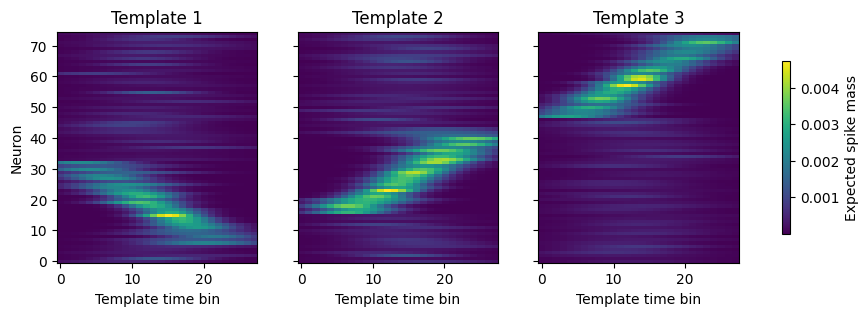

In [8]:
fig, axes = plt.subplots(1, ppseq.n_templates, figsize=(11, 3), sharey=True)
for template_id, ax in enumerate(axes):
    im = ax.imshow(ppseq.templates[template_id], aspect="auto", origin="lower")
    ax.set_xlabel("Template time bin")
    ax.set_title(f"Template {template_id + 1}")
axes[0].set_ylabel("Neuron")
fig.colorbar(im, ax=axes, label="Expected spike mass", shrink=0.75)
plt.show()

## Score post-task ripple windows

Now simulate a short post-task period with ripple windows that contain the same three sequence motifs. A shuffled control uses the same event times and neuron groups, but scrambles each sequence order.

In [9]:
post_duration = 5.0
post_sequence_starts = {
    0: [0.35, 3.30],
    1: [1.15, 4.05],
    2: [2.25],
}
control_orders = {
    sequence_id: np.random.default_rng(sequence_id).permutation(order)
    for sequence_id, order in sequence_orders.items()
}

post_spike_times, post_neuron_ids, post_sequence_ids = simulate_ppseq_spikes(
    sequence_orders,
    post_sequence_starts,
    n_neurons=n_neurons,
    duration=post_duration,
    template_duration_s=template_duration_s,
    background_rate=0.25,
    seed=4,
)
control_spike_times, control_neuron_ids, _ = simulate_ppseq_spikes(
    control_orders,
    post_sequence_starts,
    n_neurons=n_neurons,
    duration=post_duration,
    template_duration_s=template_duration_s,
    background_rate=0.25,
    seed=4,
)

post_counts, post_time_centers = ppseq.bin_spikes(
    post_spike_times,
    post_neuron_ids,
    start=0.0,
    stop=post_duration,
    n_neurons=n_neurons,
)
control_counts, _ = ppseq.bin_spikes(
    control_spike_times,
    control_neuron_ids,
    start=0.0,
    stop=post_duration,
    n_neurons=n_neurons,
)

ripple_intervals = np.array(
    [[start, start + template_duration_s] for starts in post_sequence_starts.values() for start in starts]
)

For visual orientation, plot the simulated post-task spikes with the same sequence color convention.

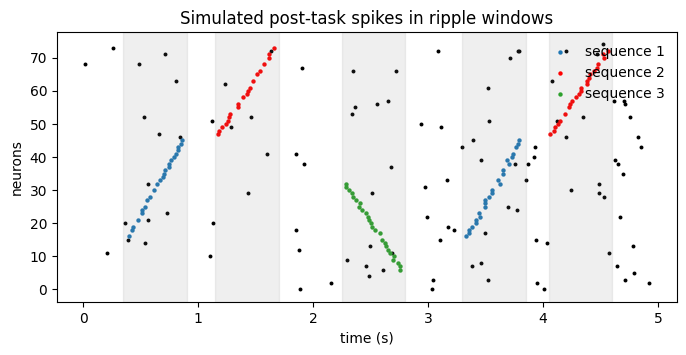

In [10]:
fig, ax = plt.subplots(figsize=(8, 3.5))
background = post_sequence_ids < 0
ax.scatter(post_spike_times[background], post_neuron_ids[background], s=8, c="black", linewidths=0)
for sequence_id, label in sequence_labels.items():
    idx = post_sequence_ids == sequence_id
    ax.scatter(
        post_spike_times[idx],
        post_neuron_ids[idx],
        s=10,
        c=sequence_colors[sequence_id],
        linewidths=0,
        label=label,
    )
for start, stop in ripple_intervals:
    ax.axvspan(start, stop, color="0.5", alpha=0.12)
ax.set_xlabel("time (s)")
ax.set_ylabel("neurons")
ax.set_title("Simulated post-task spikes in ripple windows")
ax.legend(loc="upper right", frameon=False)
plt.show()

`score_events` freezes the task templates, transforms the full post-task matrix once by default, and summarizes template amplitudes inside each event. If you already computed `post_result = ppseq.transform(post_counts)`, pass `result=post_result` so ripple scoring does not infer amplitudes a second time. Use `method="per_event"` when you specifically want a separate event-local transform. The most useful event-level outputs are:

- `template_k_max`: the largest instantaneous template strength in the event.
- `template_k_sum`: total template strength across the event.
- `likelihood_gain`: Poisson log-likelihood improvement over a background-only model.

In [11]:
matching_scores = ppseq.score_events(
    post_counts,
    ripple_intervals,
    post_time_centers,
    num_iter=20,
    method="full",
)
control_scores = ppseq.score_events(
    control_counts,
    ripple_intervals,
    post_time_centers,
    num_iter=20,
    method="full",
)

matching_scores

,start,stop,duration,best_template,likelihood_gain,template_0_sum,template_0_mean,template_0_max,template_1_sum,template_1_mean,template_1_max,template_2_sum,template_2_mean,template_2_max
0,0.35,0.90,0.55,1,251.335465,0.714662,0.025524,0.200629,9.919661,0.354274,8.397588,3.018899,0.107818,1.081700
1,3.30,3.85,0.55,1,278.251345,5.798348,0.207084,2.340818,6.293349,0.224762,1.804141,4.370909,0.156104,0.943906
2,1.15,1.70,0.55,2,196.472176,3.401456,0.121481,2.585064,2.114610,0.075522,0.575138,8.504713,0.303740,8.131318
3,4.05,4.60,0.55,2,267.515932,8.028685,0.286739,2.984959,4.528591,0.161735,2.657567,14.121366,0.504335,6.181667
4,2.25,2.80,0.55,0,294.652617,35.271221,1.259686,33.132626,1.540529,0.055019,1.154504,3.057286,0.109189,0.981611


Compare the matched post-task sequences against shuffled-order controls. The `best_template` labels are arbitrary because PPSeq is unsupervised; the important part is that fixed task templates explain matched ripple spikes better than shuffled-order controls.

In [12]:
template_max_cols = [f"template_{k}_max" for k in range(ppseq.n_templates)]
template_sum_cols = [f"template_{k}_sum" for k in range(ppseq.n_templates)]

summary = {
    "matched_likelihood_gain": matching_scores["likelihood_gain"].mean(),
    "control_likelihood_gain": control_scores["likelihood_gain"].mean(),
    "matched_best_template_max": matching_scores[template_max_cols].max(axis=1).mean(),
    "control_best_template_max": control_scores[template_max_cols].max(axis=1).mean(),
    "matched_total_template_strength": matching_scores[template_sum_cols].sum(axis=1).mean(),
    "control_total_template_strength": control_scores[template_sum_cols].sum(axis=1).mean(),
}
summary

{'matched_likelihood_gain': np.float64(257.64550714631207),
 'control_likelihood_gain': np.float64(246.9135430773909),
 'matched_best_template_max': np.float64(11.636803496852787),
 'control_best_template_max': np.float64(6.100122867297855),
 'matched_total_template_strength': np.float64(22.136857124600112),
 'control_total_template_strength': np.float64(28.005007189912032)}

You can also transform the whole post-task matrix to obtain continuous template-amplitude traces.

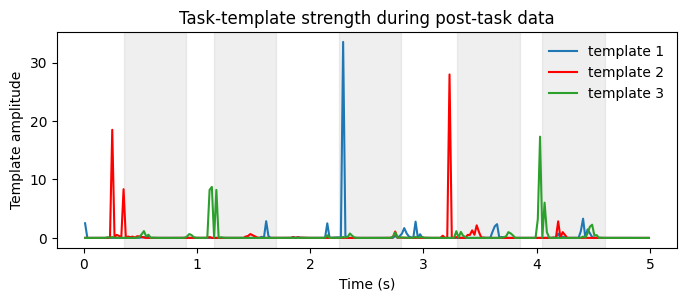

In [13]:
post_result = ppseq.transform(post_counts, num_iter=25)

fig, ax = plt.subplots(figsize=(8, 2.8))
for template_id, color in enumerate(["tab:blue", "red", "tab:green"]):
    ax.plot(
        post_time_centers,
        post_result.amplitudes[template_id],
        color=color,
        label=f"template {template_id + 1}",
    )
for start, stop in ripple_intervals:
    ax.axvspan(start, stop, color="0.5", alpha=0.12)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Template amplitude")
ax.set_title("Task-template strength during post-task data")
ax.legend(frameon=False)
plt.show()

## Real CellExplorer session data

For a real session, the main difference is data loading. The analysis is still: fit task counts, transform post-task counts, then score ripples.

In [23]:
import nelpy as nel
import numpy as np

from neuro_py.ensemble.ppseq import PPSeq
from neuro_py.io import loading
from neuro_py.session.locate_epochs import compress_repeated_epochs, find_pre_task_post
import neuro_py as npy

Load the HMC1 day8 session, restrict to a pre-task-post epoch structure, and select CA1 pyramidal cells. The same pattern works for any cell subset supported by `load_spikes`.

In [25]:
basepath = r"S:\data\HMC\HMC1\day8"

epoch_df = compress_repeated_epochs(loading.load_epoch(basepath))
_, pre_task_post_idx = find_pre_task_post(epoch_df.environment)
if pre_task_post_idx is None:
    raise ValueError("Could not find a pre-task-post epoch pattern")

pre_task_post = epoch_df.iloc[pre_task_post_idx]
pre_row = pre_task_post.iloc[0]
task_row = pre_task_post.iloc[1]
post_row = pre_task_post.iloc[2]

pre_epoch = nel.EpochArray([[pre_row.startTime, pre_row.stopTime]])
task_epoch = nel.EpochArray([[task_row.startTime, task_row.stopTime]])
post_epoch = nel.EpochArray([[post_row.startTime, post_row.stopTime]])
pre_start, pre_stop = pre_row.startTime, pre_row.stopTime
post_start, post_stop = post_row.startTime, post_row.stopTime

st, cell_metrics = loading.load_spikes(
    basepath,
    brainRegion="CA1",
    putativeCellType="Pyramidal Cell",
)
ripples = loading.load_ripples_events(basepath)

nrem = loading.load_SleepState_states(basepath, return_epoch_array=True)["NREMstate"]

# restrict ripples to nrem epochs
idx = npy.process.in_intervals(ripples.peaks, nrem.data)

ripples = ripples[idx]

Bin spikes with the `PPSeq` helper. For `nelpy.SpikeTrainArray` inputs, this uses nelpy's binning directly. For raw spike-time arrays, `PPSeq.bin_spikes` delegates interval counting to `neuro_py.process.peri_event.count_in_interval`.

In [16]:
bin_size = 0.02
template_duration_s = 0.30
template_duration_bins = int(np.round(template_duration_s / bin_size))

ppseq_real = PPSeq(
    n_templates=2, # since this is linear track we expect 2 sequences corresponding to the two running directions
    template_duration=template_duration_bins,
    bin_size=bin_size,
    sequence_frac=0.5,
    random_state=0,
)

pre_counts, pre_time_centers = ppseq_real.bin_spikes(st[pre_epoch])
task_counts, task_time_centers = ppseq_real.bin_spikes(st[task_epoch])
post_counts, post_time_centers = ppseq_real.bin_spikes(st[post_epoch])

Now that the binned matrix shape is known, set `n_neurons` on the model before fitting. This keeps the tutorial robust to the exact `nelpy` attribute names available in the installed version.

In [17]:
ppseq_real.n_neurons = task_counts.shape[0]

fit_result = ppseq_real.fit(task_counts, num_iter=75)

Restrict ripples to pre-task and post-task sleep, then score each ripple against a replay bank containing each task template in its learned direction and in reverse. `score_replay_events` returns both the event table and the sleep-wide replay transform result, so reruns can pass `result=pre_replay_result` or `result=post_replay_result` to avoid repeated inference.

In [27]:
all_ripple_intervals = np.column_stack([ripples.start, ripples.stop])


def restrict_intervals(intervals, start, stop):
    return intervals[(intervals[:, 0] >= start) & (intervals[:, 1] <= stop)]


pre_ripple_intervals = restrict_intervals(all_ripple_intervals, pre_start, pre_stop)
post_ripple_intervals = restrict_intervals(all_ripple_intervals, post_start, post_stop)

if len(pre_ripple_intervals) == 0:
    raise ValueError("Pre-task sleep contains no ripples, so a baseline sequentiality threshold cannot be computed")
if len(post_ripple_intervals) == 0:
    raise ValueError("Post-task sleep contains no ripples to score")

pre_scores, pre_replay_result = ppseq_real.score_replay_events(
    pre_counts,
    pre_ripple_intervals,
    pre_time_centers,
    num_iter=35,
)
pre_scores["sleep_epoch"] = "pre"

post_scores, post_replay_result = ppseq_real.score_replay_events(
    post_counts,
    post_ripple_intervals,
    post_time_centers,
    num_iter=35,
)
post_scores["sleep_epoch"] = "post"

ripple_scores = pd.concat([pre_scores, post_scores], ignore_index=True)
ripple_scores.head()

,start,stop,duration,best_template,best_direction,best_replay,best_replay_sum,best_replay_max,likelihood_gain,template_0_forward_sum,...,template_1_forward_sum,template_1_forward_mean,template_1_forward_max,template_0_reverse_sum,template_0_reverse_mean,template_0_reverse_max,template_1_reverse_sum,template_1_reverse_mean,template_1_reverse_max,sleep_epoch
0,77.2312,77.3376,0.1064,1,forward,template_1_forward,6.266041,4.942936,298.295316,2.683807,...,6.266041,1.253208,4.942936,0.561627,0.112325,0.545486,0.033571,0.006714,0.023492,pre
1,78.7672,78.8040,0.0368,1,forward,template_1_forward,9.962894,9.619669,20.007862,0.028543,...,9.962894,4.981447,9.619669,0.022258,0.011129,0.015374,0.093048,0.046524,0.065832,pre
2,78.8960,78.9528,0.0568,0,reverse,template_0_reverse,0.024376,0.010781,103.510910,0.019128,...,0.011251,0.003750,0.003879,0.024376,0.008125,0.010781,0.009992,0.003331,0.003587,pre
3,79.1528,79.2032,0.0504,1,reverse,template_1_reverse,8.540815,5.602641,19.018569,0.010207,...,2.089107,1.044554,2.085100,0.008667,0.004333,0.004449,8.540815,4.270408,5.602641,pre
4,79.6064,79.6864,0.0800,0,reverse,template_0_reverse,0.013672,0.006670,281.409533,0.006973,...,0.007194,0.001798,0.001956,0.013672,0.003418,0.006670,0.007631,0.001908,0.002372,pre


Use the pre-sleep likelihood-gain distribution as a baseline. Here a ripple is called replay-like when its forward/reverse replay-bank likelihood gain is above the pre-sleep 95th percentile.

In [28]:
replay_sum_cols = [
    c
    for c in ripple_scores.columns
    if c.endswith("_sum") and c not in {"best_replay_sum"}
]

ripple_scores["total_replay_strength"] = ripple_scores[replay_sum_cols].sum(axis=1)
sequential_threshold = pre_scores["likelihood_gain"].quantile(0.95)
if not np.isfinite(sequential_threshold):
    raise ValueError("Pre-task sleep likelihood gains are not finite, so a baseline threshold cannot be computed")

ripple_scores["is_replay_like"] = ripple_scores["likelihood_gain"] > sequential_threshold
sleep_durations_min = pd.Series(
    {
        "pre": (pre_stop - pre_start) / 60,
        "post": (post_stop - post_start) / 60,
    }
)

sleep_summary = (
    ripple_scores.groupby("sleep_epoch")
    .agg(
        n_ripples=("likelihood_gain", "size"),
        median_likelihood_gain=("likelihood_gain", "median"),
        mean_likelihood_gain=("likelihood_gain", "mean"),
        fraction_replay_like=("is_replay_like", "mean"),
        n_replay_like=("is_replay_like", "sum"),
    )
    .reindex(["pre", "post"])
)
sleep_summary["replay_like_ripple_rate_per_min"] = (
    sleep_summary["n_replay_like"] / sleep_durations_min
)
direction_summary = (
    ripple_scores[ripple_scores["is_replay_like"]]
    .groupby(["sleep_epoch", "best_direction"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=["pre", "post"], fill_value=0)
)
sleep_summary

,n_ripples,median_likelihood_gain,mean_likelihood_gain,fraction_replay_like,n_replay_like,replay_like_ripple_rate_per_min
sleep_epoch,,,,,,
pre,584,187.499400,202.328622,0.051370,30,0.188589
post,3267,246.069296,266.008341,0.138047,451,2.242873


Plot the pre/post comparison as a consolidation-style summary. If task sequence replay is enriched after behavior, post-task sleep should show larger replay-bank likelihood gains, a larger fraction of ripples above the pre-sleep baseline threshold, and a readable forward/reverse composition.

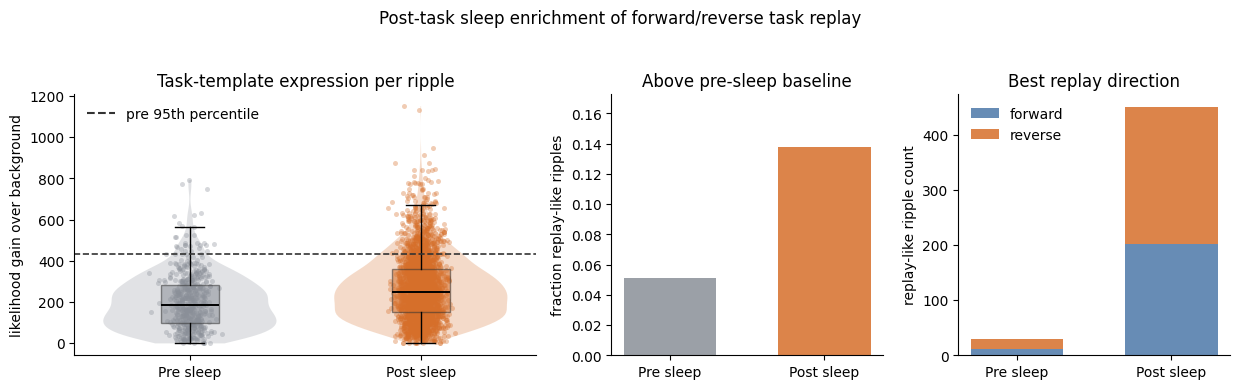

In [29]:
from matplotlib.lines import Line2D

epoch_order = ["pre", "post"]
epoch_labels = ["Pre sleep", "Post sleep"]
epoch_colors = {"pre": "#8a8f98", "post": "#d66f2a"}
likelihood_by_epoch = [
    ripple_scores.loc[ripple_scores["sleep_epoch"] == epoch, "likelihood_gain"]
    .dropna()
    .to_numpy()
    for epoch in epoch_order
]

fig, (ax_dist, ax_frac, ax_dir) = plt.subplots(
    1,
    3,
    figsize=(12.5, 3.7),
    gridspec_kw={"width_ratios": [1.7, 1.0, 1.0]},
)

positions = np.arange(len(epoch_order))
violins = ax_dist.violinplot(
    likelihood_by_epoch,
    positions=positions,
    widths=0.75,
    showmeans=False,
    showmedians=False,
    showextrema=False,
)
for body, epoch in zip(violins["bodies"], epoch_order):
    body.set_facecolor(epoch_colors[epoch])
    body.set_edgecolor("none")
    body.set_alpha(0.25)

box = ax_dist.boxplot(
    likelihood_by_epoch,
    positions=positions,
    widths=0.25,
    patch_artist=True,
    showfliers=False,
    medianprops={"color": "black", "linewidth": 1.4},
)
for patch, epoch in zip(box["boxes"], epoch_order):
    patch.set_facecolor(epoch_colors[epoch])
    patch.set_alpha(0.55)
    patch.set_edgecolor("#333333")

rng = np.random.default_rng(0)
for position, epoch, values in zip(positions, epoch_order, likelihood_by_epoch):
    jitter = rng.normal(0, 0.045, size=len(values))
    ax_dist.scatter(
        np.full(len(values), position) + jitter,
        values,
        s=13,
        color=epoch_colors[epoch],
        alpha=0.35,
        linewidth=0,
    )

ax_dist.axhline(sequential_threshold, color="#333333", linestyle="--", linewidth=1.2)
ax_dist.set_xticks(positions, epoch_labels)
ax_dist.set_ylabel("likelihood gain over background")
ax_dist.set_title("Task-template expression per ripple")
ax_dist.spines[["top", "right"]].set_visible(False)
ax_dist.legend(
    handles=[Line2D([0], [0], color="#333333", linestyle="--", label="pre 95th percentile")],
    frameon=False,
    loc="upper left",
)

fractions = sleep_summary.loc[epoch_order, "fraction_replay_like"].to_numpy(dtype=float)
ax_frac.bar(
    positions,
    fractions,
    color=[epoch_colors[epoch] for epoch in epoch_order],
    alpha=0.85,
    width=0.6,
)
ax_frac.set_xticks(positions, epoch_labels)
ax_frac.set_ylabel("fraction replay-like ripples")
ax_frac.set_ylim(0, min(1.0, max(0.1, np.nanmax(fractions) * 1.25)))
ax_frac.set_title("Above pre-sleep baseline")
ax_frac.spines[["top", "right"]].set_visible(False)

for direction in ["forward", "reverse"]:
    if direction not in direction_summary.columns:
        direction_summary[direction] = 0
direction_counts = direction_summary.loc[epoch_order, ["forward", "reverse"]]
bottom = np.zeros(len(epoch_order), dtype=float)
direction_colors = {"forward": "#4c78a8", "reverse": "#d66f2a"}
for direction in ["forward", "reverse"]:
    values = direction_counts[direction].to_numpy(dtype=float)
    ax_dir.bar(
        positions,
        values,
        bottom=bottom,
        color=direction_colors[direction],
        alpha=0.85,
        width=0.6,
        label=direction,
    )
    bottom += values
ax_dir.set_xticks(positions, epoch_labels)
ax_dir.set_ylabel("replay-like ripple count")
ax_dir.set_title("Best replay direction")
ax_dir.spines[["top", "right"]].set_visible(False)
ax_dir.legend(frameon=False)

fig.suptitle("Post-task sleep enrichment of forward/reverse task replay", y=1.04)
fig.tight_layout()

## Practical notes

- Fit templates on behavior epochs where the sequence should be expressed, such as maze running trials or specific trajectory directions.
- Score sharp wave ripples in pre-task and post-task sleep with fixed forward and reversed task templates. This asks: "How strongly is this learned behavioral template expressed in this ripple, and in which direction?"
- Keep the replay transform result returned by `score_replay_events` for large real datasets. Passing `result=pre_replay_result` or `result=post_replay_result` makes reruns mostly event summarization.
- Use the pre-sleep `likelihood_gain` distribution as a baseline when asking whether task replay is enriched after behavior.
- `likelihood_gain` is often more useful than raw total amplitude because raw amplitude can track total spike count, while likelihood gain asks whether the learned forward/reverse template bank explains the spikes better than background.
- Use explicit seconds and bin sizes throughout. `template_duration` is in bins, while ripple intervals and `time_centers` are in seconds.